In [118]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.linear_model import LogisticRegression
import numpy as np
from sklearn.model_selection import train_test_split

In [119]:
df = pd.read_csv("Downloads/diabetes.csv")

In [120]:
#data loading and exploration
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [121]:
df.shape

(769, 9)

In [122]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 769 entries, 0 to 768
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               769 non-null    int64  
 1   Glucose                   769 non-null    int64  
 2   BloodPressure             769 non-null    int64  
 3   SkinThickness             769 non-null    int64  
 4   Insulin                   769 non-null    int64  
 5   BMI                       769 non-null    float64
 6   DiabetesPedigreeFunction  769 non-null    float64
 7   Age                       769 non-null    int64  
 8   Outcome                   769 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.2 KB


In [123]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,769.000000,769.000000,769.000000,769.000000,769.000000,769.000000,769.000000,769.000000,769.000000
mean,3.841352,120.858257,69.106632,20.550065,79.695709,31.990507,0.471672,33.227568,0.348505
std,3.368946,31.967626,19.343229,15.946293,115.204894,7.879235,0.331161,11.758373,0.476807
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.244000,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,29.000000,32.000000,0.371000,29.000000,0.000000
75%,6.000000,140.000000,80.000000,32.000000,127.000000,36.600000,0.626000,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [124]:
df.duplicated().sum()

np.int64(1)

In [125]:
 #PRATICAL2 DATApreprocessing
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [126]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df_scaled = pd.DataFrame(
    scaler.fit_transform(df),
    columns=df.columns
)

df_scaled.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,0.352941,0.743719,0.590164,0.353535,0.000000,0.500745,0.234415,0.483333,1.0
1,0.058824,0.427136,0.540984,0.292929,0.000000,0.396423,0.116567,0.166667,0.0
2,0.470588,0.919598,0.524590,0.000000,0.000000,0.347243,0.253629,0.183333,1.0
3,0.058824,0.447236,0.540984,0.232323,0.111111,0.418778,0.038002,0.000000,0.0
4,0.000000,0.688442,0.327869,0.353535,0.198582,0.642325,0.943638,0.200000,1.0


In [127]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_standard = pd.DataFrame(
    scaler.fit_transform(df),
    columns=df.columns
)

df_standard.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,0.641166,0.849591,0.149678,0.906752,-0.692224,0.204403,0.469345,1.427353,1.367261
1,-0.843944,-1.122435,-0.160710,0.530245,-0.692224,-0.684586,-0.364629,-0.189569,-0.731389
2,1.235209,1.945161,-0.264173,-1.289544,-0.692224,-1.103681,0.605319,-0.104467,1.367261
3,-0.843944,-0.997227,-0.160710,0.153737,0.124245,-0.494088,-0.920611,-1.040580,-0.731389
4,-1.140966,0.505269,-1.505725,0.906752,0.766997,1.410889,5.488294,-0.019366,1.367261


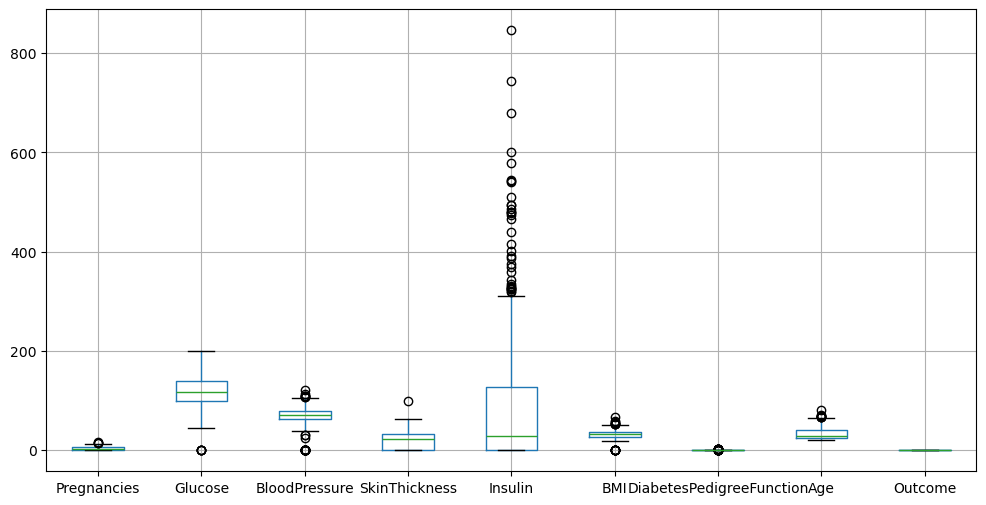

In [128]:
import matplotlib.pyplot as plt

df.boxplot(figsize=(12,6))

plt.show()

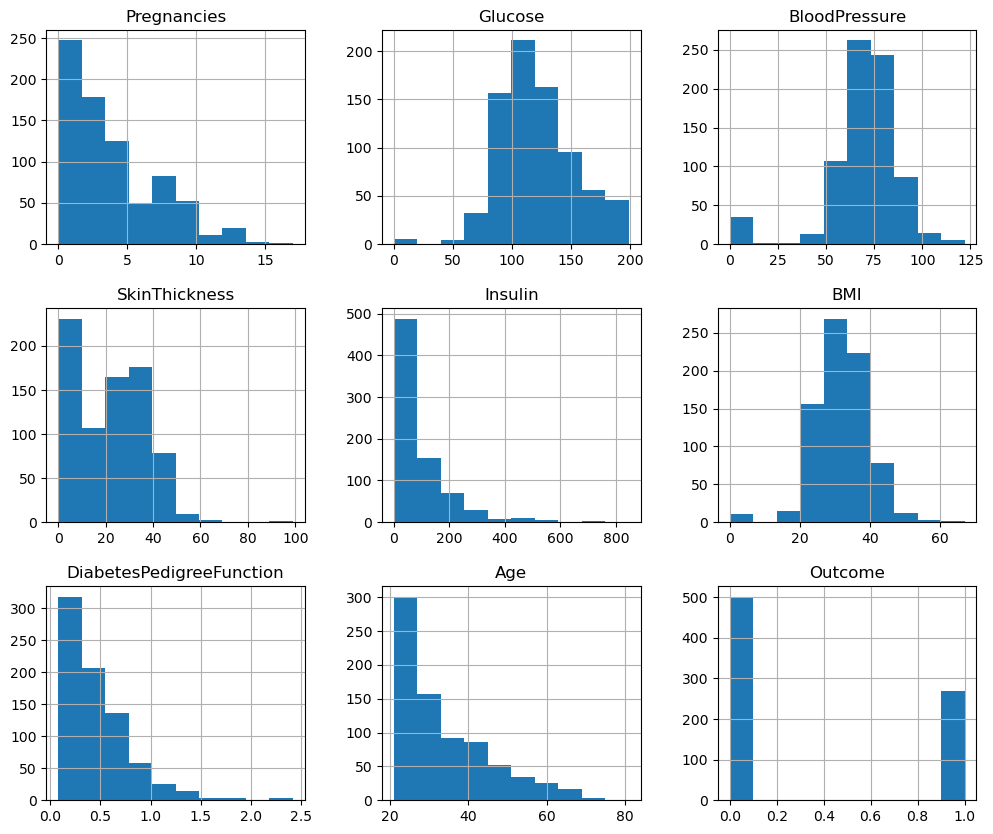

In [129]:
#practical3
import matplotlib.pyplot as plt

df.hist(figsize=(12,10))

plt.show()

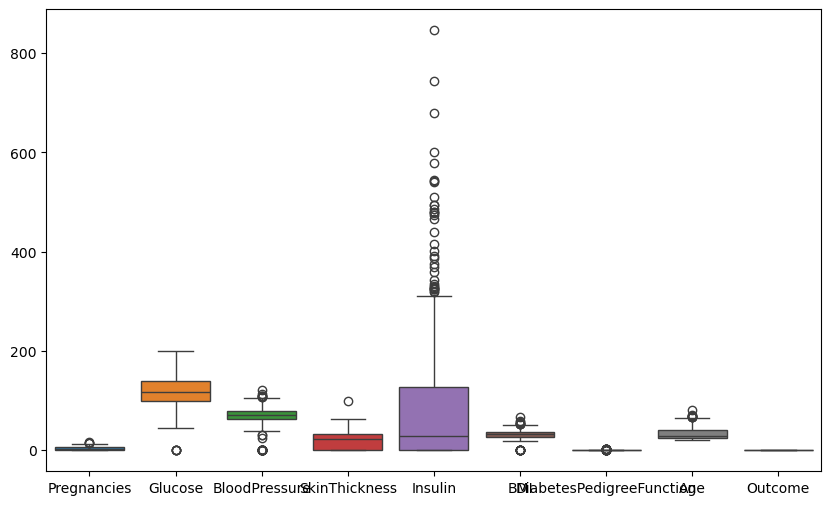

In [130]:
 #boxplot 
import seaborn as sns

plt.figure(figsize=(10,6))

sns.boxplot(data=df)

plt.show()

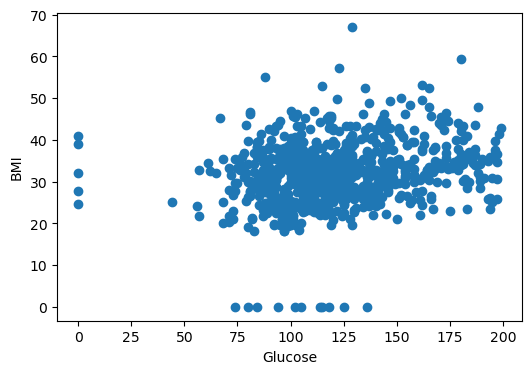

In [131]:
plt.figure(figsize=(6,4))

plt.scatter(df["Glucose"], df["BMI"])

plt.xlabel("Glucose")
plt.ylabel("BMI")

plt.show()

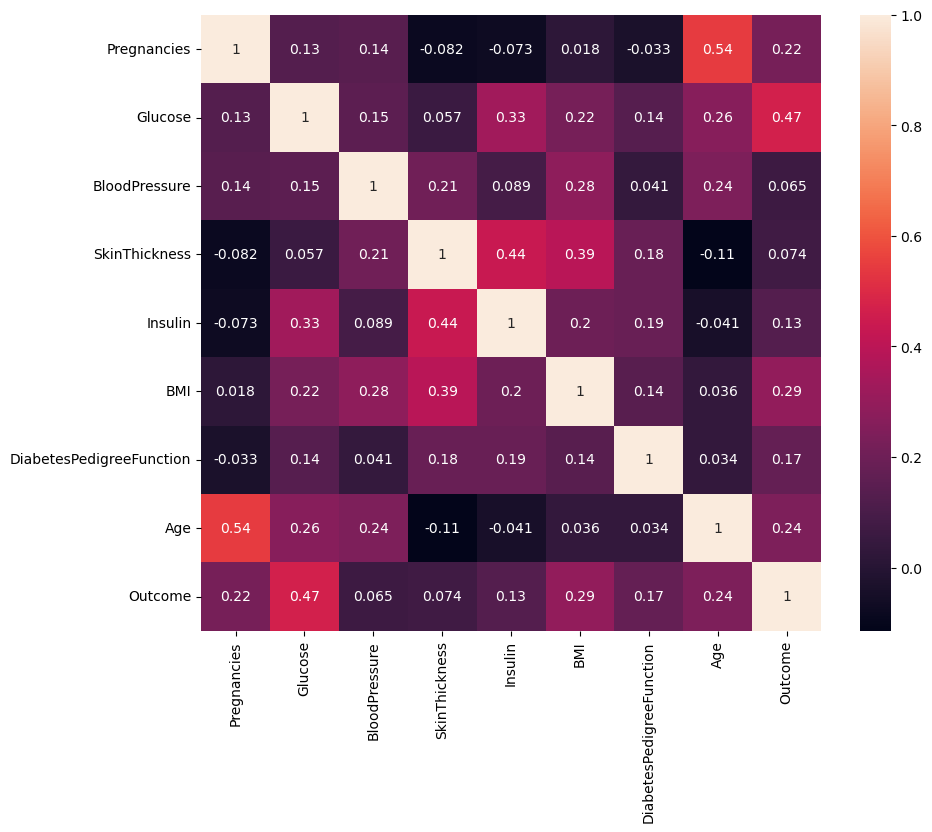

In [132]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(), annot=True)

plt.show()

In [133]:
df.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.130293,0.141165,-0.082332,-0.072717,0.017896,-0.032982,0.544777,0.222522
Glucose,0.130293,1.000000,0.152461,0.056539,0.331876,0.221185,0.137787,0.264242,0.467018
BloodPressure,0.141165,0.152461,1.000000,0.207352,0.088864,0.281785,0.041230,0.239357,0.065002
SkinThickness,-0.082332,0.056539,0.207352,1.000000,0.435933,0.392280,0.183445,-0.114625,0.074081
Insulin,-0.072717,0.331876,0.088864,0.435933,1.000000,0.197974,0.185413,-0.041345,0.131121
BMI,0.017896,0.221185,0.281785,0.392280,0.197974,1.000000,0.140747,0.036452,0.292777
DiabetesPedigreeFunction,-0.032982,0.137787,0.041230,0.183445,0.185413,0.140747,1.000000,0.034076,0.174209
Age,0.544777,0.264242,0.239357,-0.114625,-0.041345,0.036452,0.034076,1.000000,0.238984
Outcome,0.222522,0.467018,0.065002,0.074081,0.131121,0.292777,0.174209,0.238984,1.000000


In [134]:
#pratical4
df.mean()

Pregnancies                   3.841352
Glucose                     120.858257
BloodPressure                69.106632
SkinThickness                20.550065
Insulin                      79.695709
BMI                          31.990507
DiabetesPedigreeFunction      0.471672
Age                          33.227568
Outcome                       0.348505
dtype: float64

In [135]:
df.median()

Pregnancies                   3.000
Glucose                     117.000
BloodPressure                72.000
SkinThickness                23.000
Insulin                      29.000
BMI                          32.000
DiabetesPedigreeFunction      0.371
Age                          29.000
Outcome                       0.000
dtype: float64

In [136]:
df.var()

Pregnancies                    11.349798
Glucose                      1021.929102
BloodPressure                 374.160490
SkinThickness                 254.284274
Insulin                     13272.167703
BMI                            62.082345
DiabetesPedigreeFunction        0.109668
Age                           138.259343
Outcome                         0.227345
dtype: float64

In [137]:
df.std()

Pregnancies                   3.368946
Glucose                      31.967626
BloodPressure                19.343229
SkinThickness                15.946293
Insulin                     115.204894
BMI                           7.879235
DiabetesPedigreeFunction      0.331161
Age                          11.758373
Outcome                       0.476807
dtype: float64

In [138]:
df.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.130293,0.141165,-0.082332,-0.072717,0.017896,-0.032982,0.544777,0.222522
Glucose,0.130293,1.000000,0.152461,0.056539,0.331876,0.221185,0.137787,0.264242,0.467018
BloodPressure,0.141165,0.152461,1.000000,0.207352,0.088864,0.281785,0.041230,0.239357,0.065002
SkinThickness,-0.082332,0.056539,0.207352,1.000000,0.435933,0.392280,0.183445,-0.114625,0.074081
Insulin,-0.072717,0.331876,0.088864,0.435933,1.000000,0.197974,0.185413,-0.041345,0.131121
BMI,0.017896,0.221185,0.281785,0.392280,0.197974,1.000000,0.140747,0.036452,0.292777
DiabetesPedigreeFunction,-0.032982,0.137787,0.041230,0.183445,0.185413,0.140747,1.000000,0.034076,0.174209
Age,0.544777,0.264242,0.239357,-0.114625,-0.041345,0.036452,0.034076,1.000000,0.238984
Outcome,0.222522,0.467018,0.065002,0.074081,0.131121,0.292777,0.174209,0.238984,1.000000


In [139]:
from scipy.stats import ttest_ind

ttest_ind(df["BMI"], df["Glucose"])

TtestResult(statistic=np.float64(-74.84976171236067), pvalue=np.float64(0.0), df=np.float64(1536.0))

In [140]:
from scipy.stats import chi2_contingency

table = pd.crosstab(df["Outcome"], df["Age"])

chi2_contingency(table)

Chi2ContingencyResult(statistic=np.float64(141.41274228086843), pvalue=np.float64(1.9721367195221438e-10), dof=51, expected_freq=array([[41.04421326, 46.9076723 , 25.4083225 , 29.96879064, 31.27178153,
        21.4993498 , 20.84785436, 22.8023407 , 18.89336801, 13.68140442,
        15.63589077, 10.42392718, 11.07542263,  9.12093628,  6.51495449,
        10.42392718, 12.37841352, 10.42392718,  7.81794538,  8.46944083,
        14.33289987, 11.72691808,  8.46944083,  5.21196359,  9.77243173,
         8.46944083,  3.90897269,  3.25747724,  3.25747724,  5.21196359,
         5.21196359,  5.21196359,  3.25747724,  3.90897269,  2.60598179,
         1.95448635,  3.25747724,  4.56046814,  1.95448635,  3.25747724,
         1.3029909 ,  2.60598179,  2.60598179,  0.65149545,  1.95448635,
         2.60598179,  1.95448635,  0.65149545,  1.3029909 ,  0.65149545,
         0.65149545,  0.65149545],
       [21.95578674, 25.0923277 , 13.5916775 , 16.03120936, 16.72821847,
        11.5006502 , 11.15214564,

In [141]:
#ANOVA
from scipy.stats import f_oneway

positive = df[df["Outcome"]==1]["BMI"]

negative = df[df["Outcome"]==0]["BMI"]

f_oneway(positive, negative)

F_onewayResult(statistic=np.float64(71.91016100065983), pvalue=np.float64(1.1512780661759226e-16))

In [142]:
#PRACTICAL5
X = df.drop("Outcome", axis=1)
y = df["Outcome"]


In [143]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [144]:
lr = LinearRegression()

In [145]:
lr.fit(X_train, y_train)

LinearRegression()

In [146]:
y_pred = lr.predict(X_test)

In [147]:
print("R2 Score:", r2_score(y_test, y_pred))

R2 Score: 0.2923968640596313


In [148]:
print("MSE:", mean_squared_error(y_test, y_pred))

MSE: 0.16111725982787953


In [149]:
print("MAE:", mean_absolute_error(y_test, y_pred))

MAE: 0.3411137069078045


In [151]:
#practical 6
log_model = LogisticRegression(random_state=42)

In [153]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

In [154]:
log_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [157]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(random_state=42, max_iter=1000)
log_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [158]:
y_pred = log_model.predict(X_test)

In [159]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7662337662337663


In [160]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[80 20]
 [16 38]]


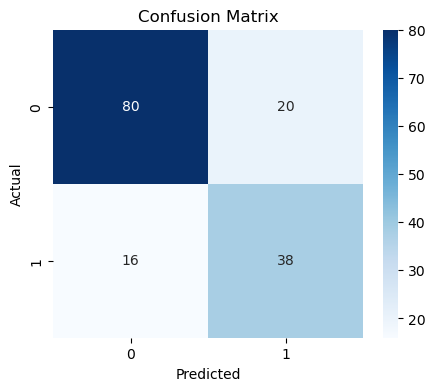

In [161]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [162]:
from sklearn.metrics import precision_score

print("Precision:", precision_score(y_test, y_pred))

Precision: 0.6551724137931034


In [163]:
from sklearn.metrics import recall_score

print("Recall:", recall_score(y_test, y_pred))

Recall: 0.7037037037037037


In [164]:
from sklearn.metrics import f1_score

print("F1 Score:", f1_score(y_test, y_pred))

F1 Score: 0.6785714285714286


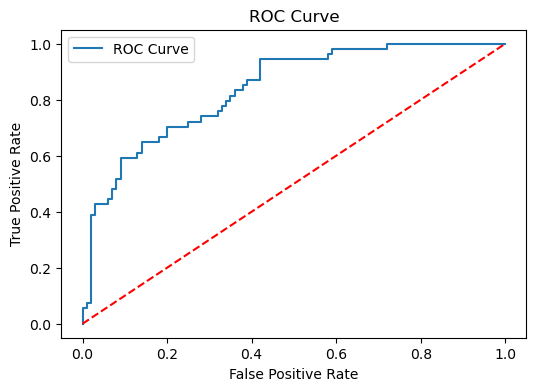

In [165]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = log_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label="ROC Curve")
plt.plot([0,1], [0,1], "r--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [166]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))

KNN Accuracy: 0.6818181818181818


In [167]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.6428571428571429


In [168]:
from sklearn.svm import SVC

svm = SVC(probability=True, random_state=42)

svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

SVM Accuracy: 0.7662337662337663


In [169]:
print("Logistic Regression:", accuracy_score(y_test, y_pred))
print("KNN:", accuracy_score(y_test, y_pred_knn))
print("Decision Tree:", accuracy_score(y_test, y_pred_dt))
print("SVM:", accuracy_score(y_test, y_pred_svm))

Logistic Regression: 0.7662337662337663
KNN: 0.6818181818181818
Decision Tree: 0.6428571428571429
SVM: 0.7662337662337663


In [170]:
#practical
X_cluster = df.drop("Outcome", axis=1)

In [171]:
from sklearn.cluster import KMeans

In [174]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

In [175]:
kmeans.fit(X_cluster)

D:\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


KMeans(n_clusters=2, n_init=10, random_state=42)

In [176]:
labels = kmeans.labels_
print(labels)

[0 0 0 0 1 0 0 0 1 0 0 0 0 1 1 0 1 0 0 0 1 0 0 0 1 0 0 0 0 0 0 1 0 0 0 1 0
 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 1 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0
 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 1 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0
 0 0 1 0 1 1 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 1 0 0 1 0 0 0 0 0 1 0 0 0 1 0 0 0 0 1 0 1 0 0 0 0 0 0 0 1 1 0 0 0 0 1 0
 0 1 0 0 0 0 1 0 0 1 0 0 0 0 1 0 0 0 0 0 0 1 1 0 0 1 1 0 0 0 0 0 1 0 0 0 1
 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 1 1 0 0 0 0 1 1 0 0
 1 1 1 0 0 0 0 0 0 0 0 1 1 1 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 1 1 0 0 0 0 0 0
 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 1 0 0 0 1 0 0 0 0 0
 1 0 0 0 1 1 0 0 0 0 0 0 1 0 0 0 0 0 1 0 1 0 1 0 0 1 0 0 0 0 0 0 0 0 0 1 0
 0 0 1 0 1 1 0 1 1 0 0 0 0 1 0 0 0 1 1 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 1
 0 0 0 0 1 1 1 0 0 0 0 0 

In [177]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


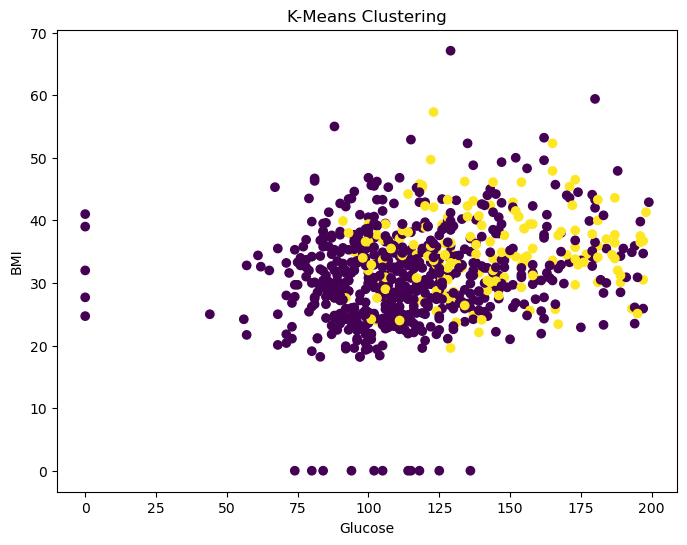

In [178]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(df["Glucose"], df["BMI"], c=labels)
plt.xlabel("Glucose")
plt.ylabel("BMI")
plt.title("K-Means Clustering")
plt.show()

In [179]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_cluster, labels)
print("Silhouette Score:", score)

Silhouette Score: 0.569102177834936


In [180]:
from scipy.cluster.hierarchy import linkage, dendrogram

In [181]:
linked = linkage(X_cluster, method="ward")

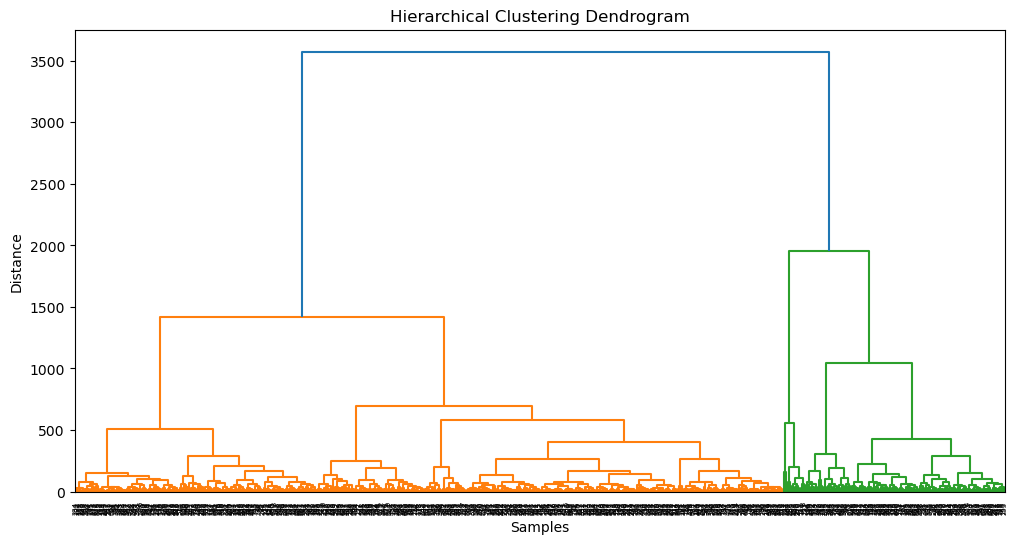

In [182]:
plt.figure(figsize=(12,6))
dendrogram(linked)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

In [183]:
#practical 8 PCA
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [184]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

In [185]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [186]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [187]:
pca_df = pd.DataFrame(X_pca, columns=["PC1","PC2"])

pca_df.head()

,PC1,PC2
0,1.073094,1.232605
1,-1.124014,-0.731182
2,-0.390019,1.602414
3,-1.119357,-1.267835
4,2.357699,-2.185986


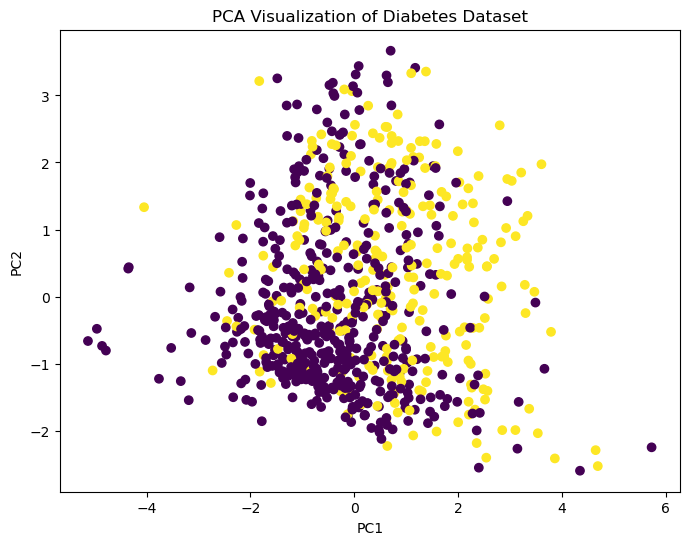

In [188]:
plt.figure(figsize=(8,6))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=y
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Visualization of Diabetes Dataset")

plt.show()

In [189]:
pca = PCA(n_components=3)

X_pca_3d = pca.fit_transform(X_scaled)

In [190]:
pca_3d_df = pd.DataFrame(
    X_pca_3d,
    columns=["PC1", "PC2", "PC3"]
)

pca_3d_df["Outcome"] = y.values

pca_3d_df.head()

,PC1,PC2,PC3,Outcome
0,1.073094,1.232605,-0.092953,1
1,-1.124014,-0.731182,0.710345,0
2,-0.390019,1.602414,-1.758812,1
3,-1.119357,-1.267835,0.659440,0
4,2.357699,-2.185986,-2.970145,1


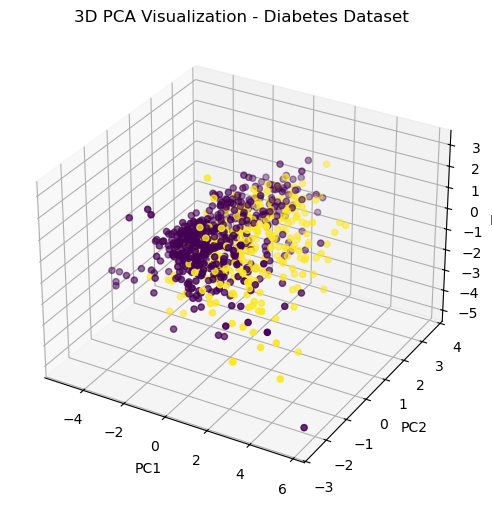

In [191]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    pca_3d_df["PC1"],
    pca_3d_df["PC2"],
    pca_3d_df["PC3"],
    c=pca_3d_df["Outcome"]
)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

ax.set_title("3D PCA Visualization - Diabetes Dataset")

plt.show()

In [192]:
import pandas as pd

df_ts = pd.read_csv("Downloads/archive (6)/airpassenger.csv.csv")

df_ts.head()

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [193]:
df_ts.columns

Index(['Month', '#Passengers'], dtype='object')

In [194]:
df_ts['Month'] = pd.to_datetime(df_ts['Month'])

df_ts.set_index('Month', inplace=True)

df_ts.head()

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [198]:
df_ts.head()

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [199]:
df_ts.columns

Index(['#Passengers'], dtype='object')

In [201]:
df_ts.columns

Index(['#Passengers'], dtype='object')

In [202]:
df_ts.head()

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


<Figure size 1000x500 with 0 Axes>

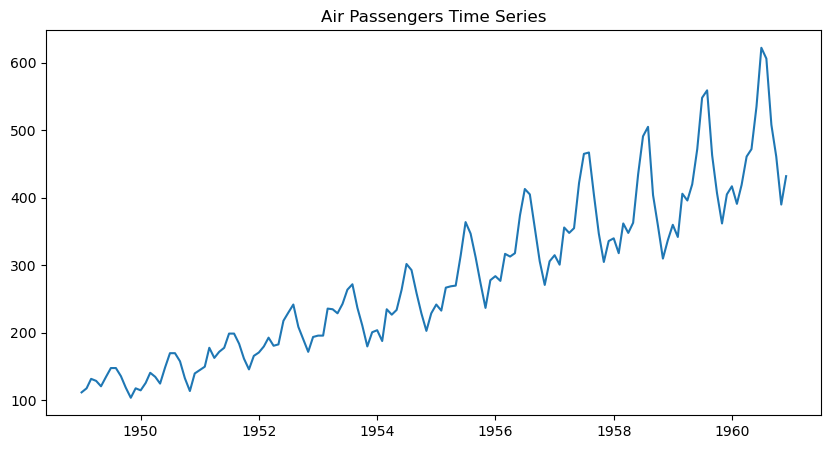

In [204]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(df_ts['#Passengers'])

plt.title("Air Passengers Time Series")

plt.show()

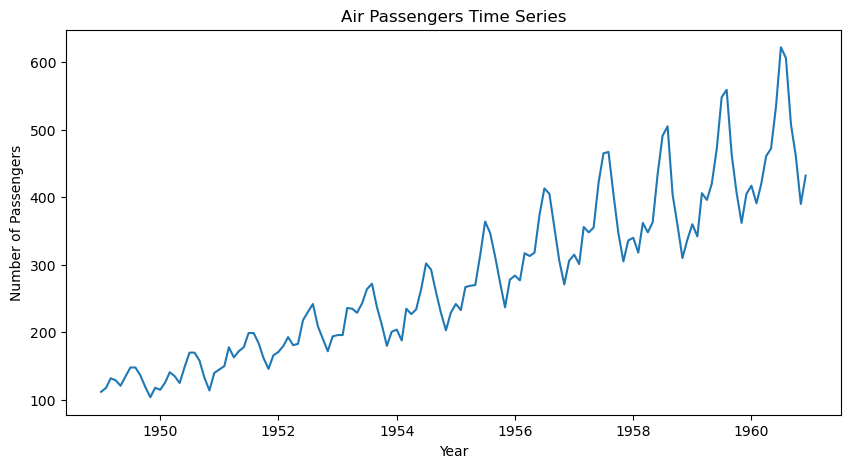

In [205]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(df_ts['#Passengers'])

plt.title("Air Passengers Time Series")
plt.xlabel("Year")
plt.ylabel("Number of Passengers")

plt.show()

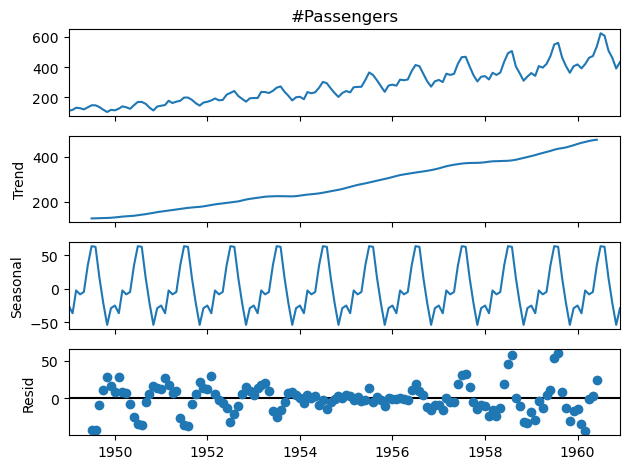

In [206]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(
    df_ts['#Passengers'],
    model='additive',
    period=12
)

decomposition.plot()

plt.show()

In [207]:
df_ts['Moving_Average'] = df_ts['#Passengers'].rolling(window=12).mean()

df_ts.head(15)

,#Passengers,Moving_Average
Month,,
1949-01-01,112,NaN
1949-02-01,118,NaN
1949-03-01,132,NaN
1949-04-01,129,NaN
1949-05-01,121,NaN
1949-06-01,135,NaN
1949-07-01,148,NaN
1949-08-01,148,NaN
1949-09-01,136,NaN


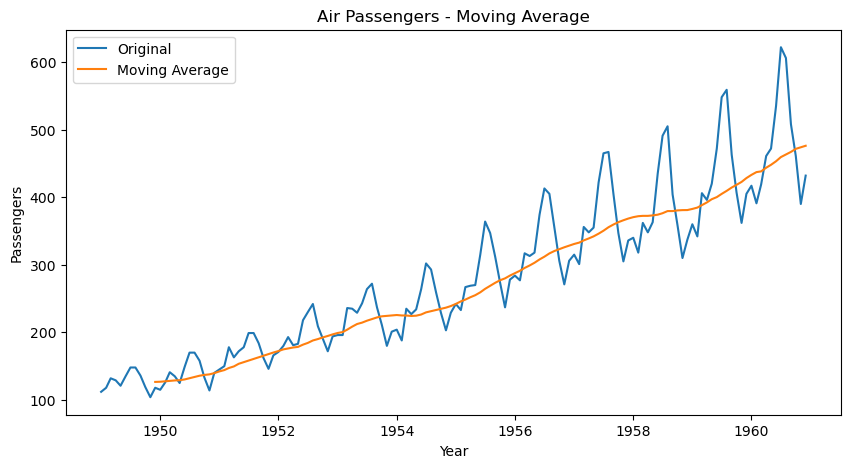

In [208]:
plt.figure(figsize=(10,5))

plt.plot(df_ts['#Passengers'], label="Original")

plt.plot(df_ts['Moving_Average'], label="Moving Average")

plt.xlabel("Year")
plt.ylabel("Passengers")

plt.title("Air Passengers - Moving Average")

plt.legend()

plt.show()

In [209]:
#ARIMA
from statsmodels.tsa.arima.model import ARIMA

In [210]:
model = ARIMA(df_ts['#Passengers'], order=(2,1,2))

model_fit = model.fit()

D:\Anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
D:\Anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
D:\Anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
D:\Anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [211]:
forecast = model_fit.forecast(steps=12)

forecast

1961-01-01    439.855832
1961-02-01    465.297925
1961-03-01    500.666979
1961-04-01    535.971034
1961-05-01    561.686948
1961-06-01    571.308847
1961-07-01    562.967333
1961-08-01    539.724498
1961-09-01    508.524953
1961-10-01    478.146618
1961-11-01    456.749375
1961-12-01    449.701210
Freq: MS, Name: predicted_mean, dtype: float64

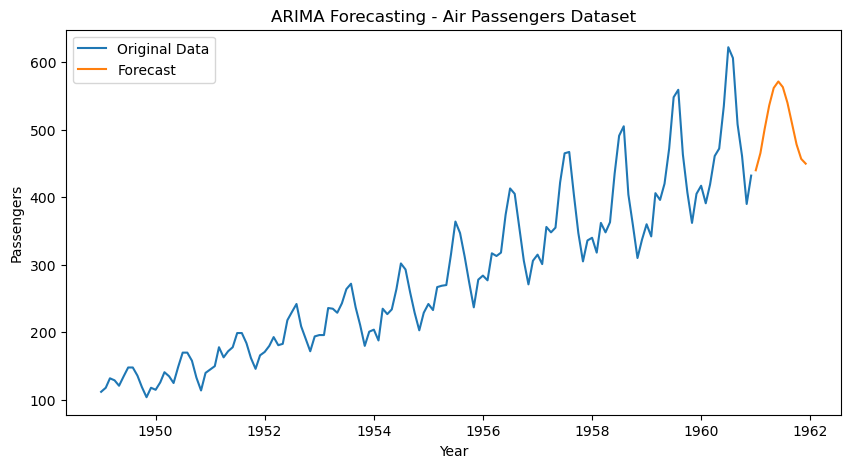

In [212]:
plt.figure(figsize=(10,5))

plt.plot(df_ts['#Passengers'], label="Original Data")

plt.plot(forecast, label="Forecast")

plt.xlabel("Year")
plt.ylabel("Passengers")

plt.title("ARIMA Forecasting - Air Passengers Dataset")

plt.legend()

plt.show()